<a href="https://colab.research.google.com/github/justlugoo/ml-administracion-sistemas-operativos/blob/main/Machine_Learning_en_Administraci%C3%B3n_de_Sistemas_Operativos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
# Cargar las tres hojas del Excel
df_so = pd.read_excel('base_datos_parcial_ml_so.xlsx', sheet_name='instalacion_SO')
df_disco = pd.read_excel('base_datos_parcial_ml_so.xlsx', sheet_name='falla_disco')
df_cluster = pd.read_excel('base_datos_parcial_ml_so.xlsx', sheet_name='clusters_laboratorio')

In [ ]:
# ── HOJA 1: instalacion_SO ──
print("=" * 50)
print("HOJA: instalacion_SO")
print(f"Registros: {df_so.shape[0]} | Variables: {df_so.shape[1]}")
print(df_so.dtypes)
print(df_so.head())

HOJA: instalacion_SO
Registros: 1000 | Variables: 12
id_equipo                     int64
ram_gb                        int64
cpu_nucleos                   int64
cpu_ghz                     float64
ssd_gb                        int64
hdd_gb                        int64
edad_equipo_anios             int64
tipo_uso                     object
virtualizacion_requerida      int64
gpu_dedicada                  int64
usuarios_estimados            int64
instalacion_recomendada      object
dtype: object
   id_equipo  ram_gb  cpu_nucleos  cpu_ghz  ssd_gb  hdd_gb  edad_equipo_anios  \
0          1      24            4     2.05     128    1000                  0   
1          2       2            4     3.68     512       0                  9   
2          3      16            4     2.10    1024       0                  2   
3          4      16            6     4.71     256    1000                  0   
4          5       4            4     2.53       0       0                  1   

          tipo

In [ ]:
# ── HOJA 2: falla_disco ──
print("=" * 50)
print("HOJA: falla_disco")
print(f"Registros: {df_disco.shape[0]} | Variables: {df_disco.shape[1]}")
print(df_disco.dtypes)
print(df_disco.head())

HOJA: falla_disco
Registros: 1000 | Variables: 12
id_disco                     int64
tipo_disco                  object
temperatura_c              float64
horas_encendido              int64
ciclos_encendido             int64
sectores_reasignados         int64
sectores_pendientes          int64
errores_irrecuperables       int64
latencia_lectura_ms        float64
desgaste_pct                 int64
velocidad_interfaz_mbps      int64
falla_30_dias                int64
dtype: object
   id_disco tipo_disco  temperatura_c  horas_encendido  ciclos_encendido  \
0         1        HDD           54.6            32659              1350   
1         2   SSD SATA           51.8            27181              1178   
2         3   SSD SATA           54.4             6514               628   
3         4   SSD SATA           38.2               50                 5   
4         5        HDD           33.2            24252              1062   

   sectores_reasignados  sectores_pendientes  errores_irrec

In [ ]:
# ── HOJA 3: clusters_laboratorio ──
print("=" * 50)
print("HOJA: clusters_laboratorio")
print(f"Registros: {df_cluster.shape[0]} | Variables: {df_cluster.shape[1]}")
print(df_cluster.dtypes)
print(df_cluster.head())


HOJA: clusters_laboratorio
Registros: 1000 | Variables: 12
id_equipo                  int64
cpu_benchmark              int64
ram_gb                     int64
tipo_disco                object
almacenamiento_gb          int64
edad_equipo_anios          int64
cpu_promedio_pct         float64
ram_promedio_pct         float64
temperatura_c            float64
tiempo_arranque_s        float64
virtualizacion_activa      int64
cluster_referencia        object
dtype: object
   id_equipo  cpu_benchmark  ram_gb tipo_disco  almacenamiento_gb  \
0          1          10542       8        SSD                256   
1          2          21309      32       NVMe                512   
2          3           2497       6        HDD                500   
3          4           7639       8       NVMe                512   
4          5           3260       6        SSD                250   

   edad_equipo_anios  cpu_promedio_pct  ram_promedio_pct  temperatura_c  \
0                  5              61.0   

PUNTO 1 — ANÁLISIS DE LAS HOJAS

instalacion_SO (1000 registros, 12 variables):
Contiene características técnicas de equipos (RAM, CPU, disco, edad, tipo de uso)
y la variable objetivo 'instalacion_recomendada' (Mínima, Estándar, Personalizada).
Permite clasificar qué tipo de instalación de SO conviene según el hardware.

falla_disco (1000 registros, 12 variables):
Registra métricas SMART de discos duros y SSD (temperatura, sectores reasignados,
desgaste, latencia) junto con la variable objetivo binaria 'falla_30_dias' (0/1).
Permite predecir si un disco fallará en los próximos 30 días.

clusters_laboratorio (1000 registros, 12 variables):
Contiene métricas de rendimiento de equipos de laboratorio (benchmark, uso de CPU/RAM,
temperatura, tiempo de arranque). La columna 'cluster_referencia' NO se usa para entrenar.
Permite agrupar equipos por perfil de desempeño mediante clustering.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# Eliminar columna identificadora
df_so2 = df_so.drop(columns=['id_equipo'])

# Codificar variable categórica 'tipo_uso'
df_so2 = pd.get_dummies(df_so2, columns=['tipo_uso'])

# Separar variable objetivo
X = df_so2.drop(columns=['instalacion_recomendada'])
y = df_so2['instalacion_recomendada']

# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(f"Entrenamiento: {X_train.shape[0]} registros")
print(f"Prueba: {X_test.shape[0]} registros")

Entrenamiento: 800 registros
Prueba: 200 registros


Exactitud del modelo: 69.00%


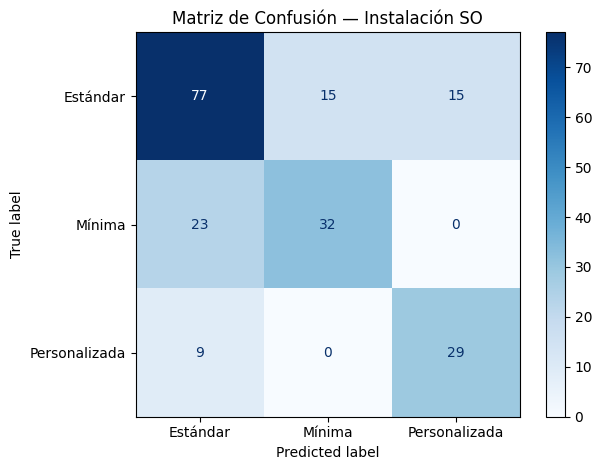

In [ ]:
# Entrenar árbol de decisión
modelo_so = DecisionTreeClassifier(random_state=42)
modelo_so.fit(X_train, y_train)

# Exactitud
y_pred = modelo_so.predict(X_test)
exactitud = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo: {exactitud:.2%}")

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=modelo_so.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo_so.classes_)
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión — Instalación SO")
plt.tight_layout()
plt.show()

# Importancia de variables
importancias = pd.Series(modelo_so.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=True)

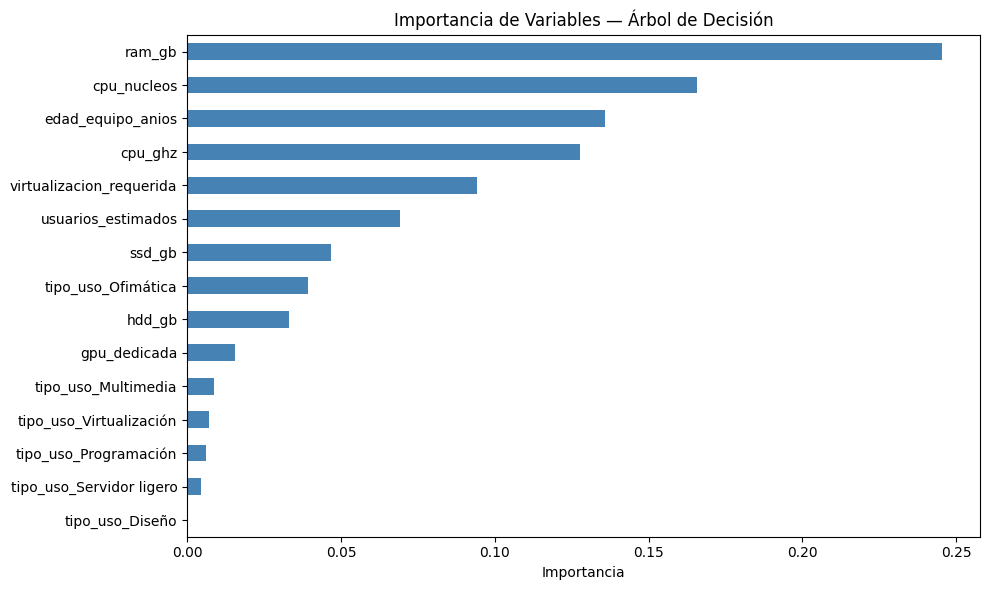

In [ ]:
plt.figure(figsize=(10, 6))
importancias.plot(kind='barh', color='steelblue')
plt.title("Importancia de Variables — Árbol de Decisión")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

PUNTO 2 — ANÁLISIS DEL MODELO

Exactitud: 69% — el modelo clasifica correctamente 7 de cada 10 equipos.

Matriz de confusión:
- Estándar: 77 correctos. Se confunde principalmente con Mínima y Personalizada (15 c/u).
- Mínima: 32 correctos. 23 equipos fueron clasificados incorrectamente como Estándar.
- Personalizada: 29 correctos. 9 equipos confundidos con Estándar.

La clase con mayor error es Mínima, posiblemente porque comparte características
de hardware con instalaciones Estándar en rangos intermedios.

Importancia de variables:
Las 5 variables más influyentes son:
1. ram_gb (≈25%) — principal determinante de la instalación recomendada.
2. cpu_nucleos (≈16%) — mayor número de núcleos orienta hacia instalaciones más robustas.
3. edad_equipo_anios (≈15%) — equipos más antiguos tienden a instalaciones mínimas.
4. cpu_ghz (≈14%) — frecuencia del procesador define capacidad de carga del SO.
5. virtualizacion_requerida (≈10%) — exige recursos adicionales del sistema.

El tipo de uso (Ofimática, Diseño, etc.) tiene baja influencia comparado con
las especificaciones físicas del hardware.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [ ]:
# Eliminar columna identificadora
df_disco2 = df_disco.drop(columns=['id_disco'])

# Codificar variable categórica 'tipo_disco'
df_disco2 = pd.get_dummies(df_disco2, columns=['tipo_disco'])

# Separar variable objetivo
X2 = df_disco2.drop(columns=['falla_30_dias'])
y2 = df_disco2['falla_30_dias']

In [ ]:
# Dividir en entrenamiento (80%) y prueba (20%)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

In [ ]:
print(f"Entrenamiento: {X2_train.shape[0]} registros")
print(f"Prueba: {X2_test.shape[0]} registros")
print(f"\nDistribución de fallas en prueba:\n{y2_test.value_counts()}")

Entrenamiento: 800 registros
Prueba: 200 registros

Distribución de fallas en prueba:
falla_30_dias
0    110
1     90
Name: count, dtype: int64


In [ ]:
# Entrenar árbol de decisión
modelo_disco = DecisionTreeClassifier(random_state=42)
modelo_disco.fit(X2_train, y2_train)

# Predicciones
y2_pred = modelo_disco.predict(X2_test)

# Métricas
exactitud2  = accuracy_score(y2_test, y2_pred)
precision2  = precision_score(y2_test, y2_pred)
recall2     = recall_score(y2_test, y2_pred)
f1_2        = f1_score(y2_test, y2_pred)

Exactitud : 77.00%
Precisión : 74.44%
Recall    : 74.44%
F1-Score  : 74.44%


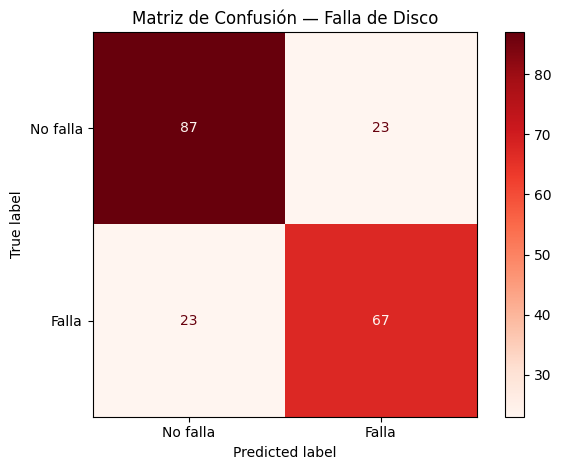

In [ ]:
print(f"Exactitud : {exactitud2:.2%}")
print(f"Precisión : {precision2:.2%}")
print(f"Recall    : {recall2:.2%}")
print(f"F1-Score  : {f1_2:.2%}")

# Matriz de confusión
cm2 = confusion_matrix(y2_test, y2_pred)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=['No falla', 'Falla'])
disp2.plot(cmap='Reds')
plt.title("Matriz de Confusión — Falla de Disco")
plt.tight_layout()
plt.show()

PUNTO 3 — ANÁLISIS DEL MODELO

Métricas obtenidas:
- Exactitud : 77% — el modelo acierta en 154 de 200 discos.
- Precisión : 74.44% — de los discos que predijo como "van a fallar", el 74% realmente falló.
- Recall    : 74.44% — el modelo detectó el 74% de los discos que realmente iban a fallar.
- F1-Score  : 74.44% — equilibrio entre precisión y recall, desempeño aceptable.

Matriz de confusión:
- Verdaderos negativos (No falla → No falla): 87 ✓
- Verdaderos positivos (Falla → Falla): 67 ✓
- Falsos negativos (Falla → No falla): 23 ✗  ← el error más crítico
- Falsos positivos (No falla → Falla): 23 ✗

Impacto de los falsos negativos en mantenimiento preventivo:
Los 23 discos clasificados como "no van a fallar" cuando en realidad SÍ fallarán
representan el error más costoso en administración de sistemas. Una falla no
anticipada puede causar pérdida irreversible de datos, caída de servicios y
tiempo de inactividad no planificado. En un entorno productivo, es preferible
un falso positivo (revisar un disco innecesariamente) que un falso negativo
(ignorar un disco que va a fallar). Por esto, en mantenimiento preventivo se
prioriza maximizar el Recall por encima de la Precisión.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np

In [ ]:
# ── RANDOM FOREST ──
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X2_train, y2_train)
y_rf_pred = modelo_rf.predict(X2_test)

# ── MÉTRICAS RANDOM FOREST ──
exactitud_rf  = accuracy_score(y2_test, y_rf_pred)
precision_rf  = precision_score(y2_test, y_rf_pred)
recall_rf     = recall_score(y2_test, y_rf_pred)
f1_rf         = f1_score(y2_test, y_rf_pred)

# ── TABLA COMPARATIVA ──
tabla = pd.DataFrame({
    'Métrica'           : ['Exactitud', 'Precisión', 'Recall', 'F1-Score'],
    'Árbol de Decisión' : [exactitud2, precision2, recall2, f1_2],
    'Random Forest'     : [exactitud_rf, precision_rf, recall_rf, f1_rf]
})
tabla[['Árbol de Decisión', 'Random Forest']] = tabla[['Árbol de Decisión', 'Random Forest']].applymap(lambda x: f"{x:.2%}")
print(tabla.to_string(index=False))

  Métrica Árbol de Decisión Random Forest
Exactitud            77.00%        82.00%
Precisión            74.44%        80.68%
   Recall            74.44%        78.89%
 F1-Score            74.44%        79.78%


/tmp/ipykernel_1815/2089980412.py:18: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  tabla[['Árbol de Decisión', 'Random Forest']] = tabla[['Árbol de Decisión', 'Random Forest']].applymap(lambda x: f"{x:.2%}")


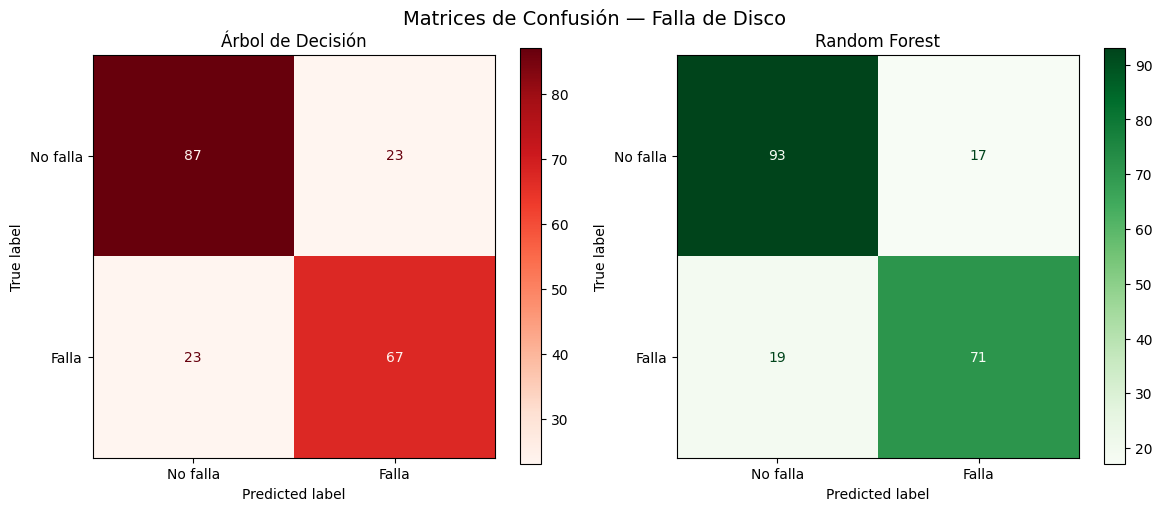

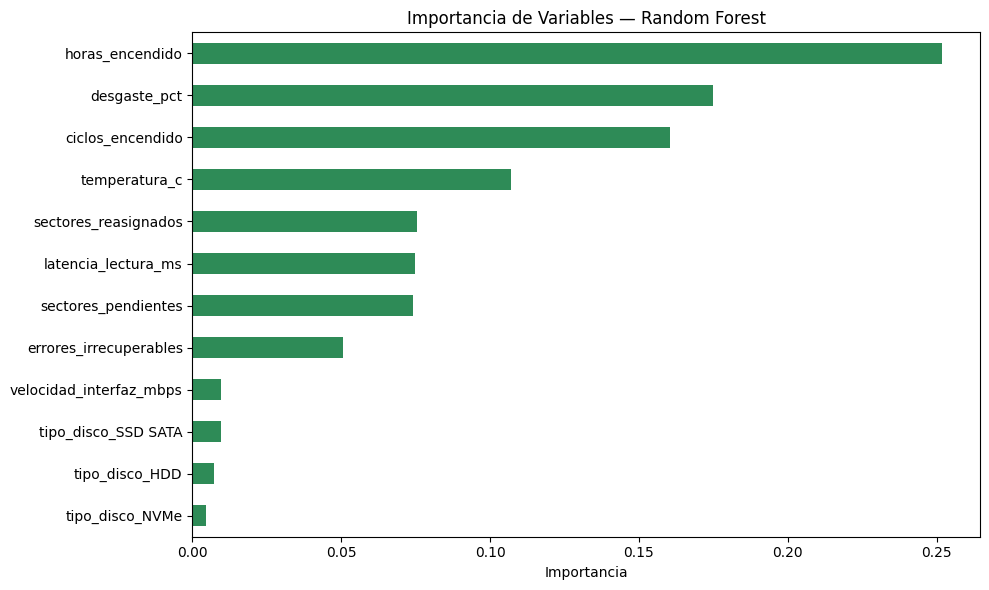

In [ ]:
# ── MATRICES DE CONFUSIÓN ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_arbol = confusion_matrix(y2_test, y2_pred)
ConfusionMatrixDisplay(cm_arbol, display_labels=['No falla', 'Falla']).plot(ax=axes[0], cmap='Reds')
axes[0].set_title("Árbol de Decisión")

cm_rf = confusion_matrix(y2_test, y_rf_pred)
ConfusionMatrixDisplay(cm_rf, display_labels=['No falla', 'Falla']).plot(ax=axes[1], cmap='Greens')
axes[1].set_title("Random Forest")

plt.suptitle("Matrices de Confusión — Falla de Disco", fontsize=14)
plt.tight_layout()
plt.show()

# ── IMPORTANCIA DE VARIABLES (Random Forest) ──
importancias_rf = pd.Series(modelo_rf.feature_importances_, index=X2.columns)
importancias_rf = importancias_rf.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importancias_rf.plot(kind='barh', color='seagreen')
plt.title("Importancia de Variables — Random Forest")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

PUNTO 4 — ANÁLISIS COMPARATIVO

Tabla de resultados:
| Métrica   | Árbol de Decisión | Random Forest |
|-----------|-------------------|---------------|
| Exactitud | 77.00%            | 82.00%        |
| Precisión | 74.44%            | 80.68%        |
| Recall    | 74.44%            | 78.89%        |
| F1-Score  | 74.44%            | 79.78%        |

Random Forest supera al árbol de decisión en todas las métricas,
con una mejora de +5% en exactitud y +5.34% en F1-Score.

Matrices de confusión:
- Árbol: 23 falsos negativos (discos que fallarán, no detectados).
- Random Forest: reduce a 19 falsos negativos — mejora crítica para
  mantenimiento preventivo.

Importancia de variables (Random Forest):
1. horas_encendido — principal indicador de desgaste acumulado.
2. desgaste_pct — porcentaje de vida útil consumida del disco.
3. ciclos_encendido — número de arranques refleja estrés mecánico.
4. temperatura_c — temperaturas elevadas aceleran el deterioro.
5. sectores_reasignados — señal directa de daño físico en el disco.

Conclusión:
Random Forest es el modelo superior. Al combinar múltiples árboles de
decisión, reduce el sobreajuste y generaliza mejor. En administración
de sistemas, esta diferencia es relevante: detectar 4 discos adicionales
en riesgo de falla puede evitar pérdidas de datos no recuperables.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

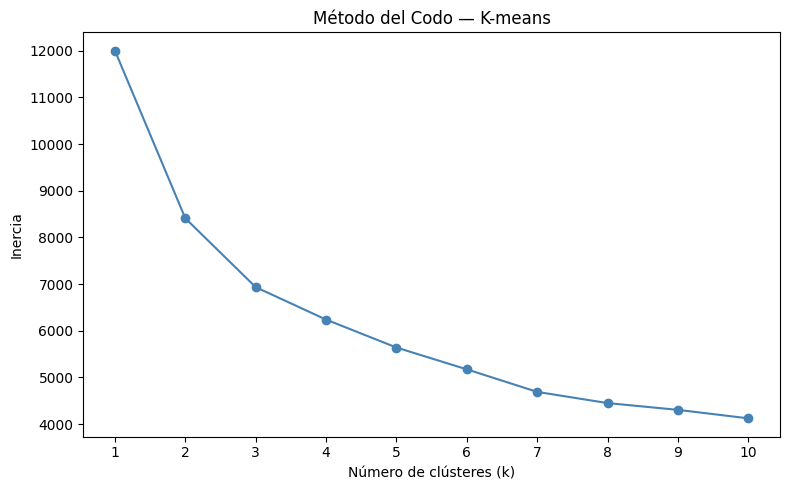

In [ ]:
# Eliminar columnas que no se usan
df_cluster2 = df_cluster.drop(columns=['id_equipo', 'cluster_referencia'])

# Codificar variable categórica 'tipo_disco'
df_cluster2 = pd.get_dummies(df_cluster2, columns=['tipo_disco'])

# Normalizar los datos
scaler = StandardScaler()
X_cluster = scaler.fit_transform(df_cluster2)

# Método del codo
inercias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inercias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inercias, marker='o', color='steelblue')
plt.title("Método del Codo — K-means")
plt.xlabel("Número de clústeres (k)")
plt.ylabel("Inercia")
plt.xticks(k_range)
plt.tight_layout()
plt.show()

Equipos por clúster:
cluster
0    386
1    306
2    308
Name: count, dtype: int64


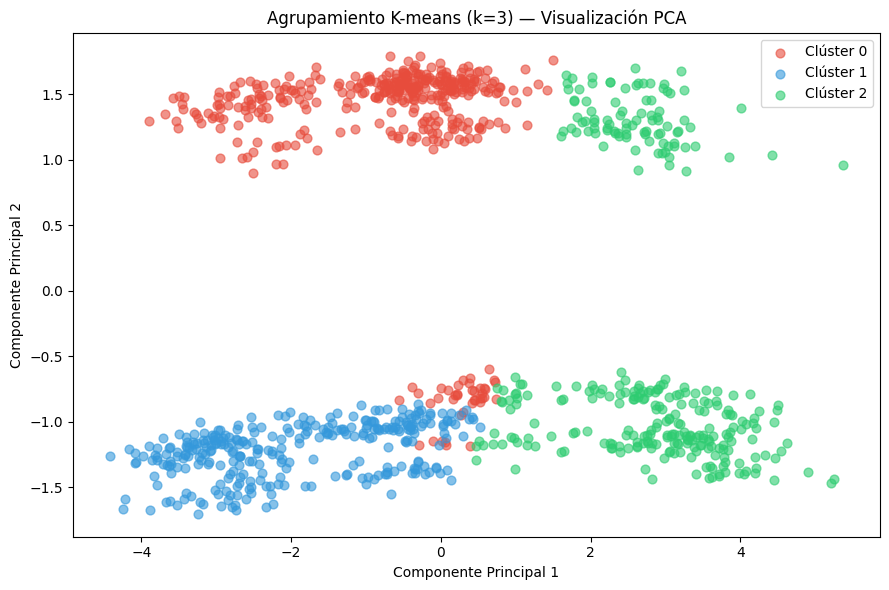


Perfil promedio por clúster:
         cpu_benchmark  ram_gb  edad_equipo_anios  cpu_promedio_pct  \
cluster                                                               
0               7064.6    10.6                6.1              53.2   
1               5084.7     8.3                7.1              57.1   
2              16448.8    28.9                2.9              33.6   

         tiempo_arranque_s  
cluster                     
0                     61.2  
1                     84.7  
2                     21.1  


In [ ]:
# Aplicar K-means con k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster)

# Cantidad de equipos por clúster
df_cluster2['cluster'] = clusters
print("Equipos por clúster:")
print(df_cluster2['cluster'].value_counts().sort_index())

# Visualización con PCA (reducir a 2 dimensiones)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(9, 6))
colores = ['#e74c3c', '#3498db', '#2ecc71']
etiquetas = ['Clúster 0', 'Clúster 1', 'Clúster 2']

for i in range(3):
    mask = clusters == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colores[i], label=etiquetas[i], alpha=0.6, s=40)

plt.title("Agrupamiento K-means (k=3) — Visualización PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend()
plt.tight_layout()
plt.show()

# Perfil promedio de cada clúster
perfil = df_cluster.drop(columns=['id_equipo', 'cluster_referencia'])
perfil = pd.get_dummies(perfil, columns=['tipo_disco'])
perfil['cluster'] = clusters
print("\nPerfil promedio por clúster:")
print(perfil.groupby('cluster')[['cpu_benchmark','ram_gb','edad_equipo_anios',
                                  'cpu_promedio_pct','tiempo_arranque_s']].mean().round(1))

PUNTO 5 — ANÁLISIS K-MEANS

Método del codo:
La curva muestra un quiebre pronunciado en k=3, confirmando que 3 clústeres
es la partición óptima para este dataset.

Distribución de equipos:
- Clúster 0: 386 equipos
- Clúster 1: 306 equipos
- Clúster 2: 308 equipos

Perfil promedio por clúster:
| Métrica           | Clúster 0 | Clúster 1 | Clúster 2 |
|-------------------|-----------|-----------|-----------|
| CPU Benchmark     | 7,064     | 5,084     | 16,448    |
| RAM (GB)          | 10.6      | 8.3       | 28.9      |
| Edad (años)       | 6.1       | 7.1       | 2.9       |
| Uso CPU (%)       | 53.2%     | 57.1%     | 33.6%     |
| Arranque (seg)    | 61.2      | 84.7      | 21.1      |

Interpretación de perfiles:

Clúster 2 → Perfil ALTO:
Equipos más nuevos (2.9 años), mayor CPU benchmark (16,448), más RAM (28.9 GB)
y arranque más rápido (21.1s). Son estaciones de trabajo o servidores recientes,
aptos para virtualización y cargas exigentes.

Clúster 0 → Perfil MEDIO:
Hardware moderado, edad intermedia (6.1 años) y arranque aceptable (61.2s).
Equipos funcionales para tareas de oficina o laboratorio estándar.

Clúster 1 → Perfil BAJO:
Equipos más antiguos (7.1 años), menor benchmark (5,084), poca RAM (8.3 GB)
y arranque lento (84.7s). Candidatos a reemplazo o instalaciones mínimas de SO.

Visualización PCA:
Los tres grupos se separan claramente en el espacio bidimensional, lo que
confirma que K-means identificó patrones reales y diferenciables en los datos.

CONCLUSIONES GENERALES

Este parcial aplicó tres técnicas de Machine Learning sobre datos reales de
administración de sistemas operativos, obteniendo los siguientes resultados:

1. Exploración de datos:
Se analizaron 3 hojas con 1,000 registros cada una, cubriendo instalación de SO,
salud de discos y rendimiento de equipos de laboratorio. Los datos presentaron
buena calidad y distribución adecuada para entrenar modelos de ML.

2. Clasificación de instalación de SO (Árbol de Decisión — 69%):
La RAM, los núcleos del CPU y la edad del equipo son los factores determinantes
para recomendar una instalación de SO. El modelo es funcional aunque presenta
margen de mejora, especialmente en la clase "Mínima".

3. Predicción de falla de disco (Árbol de Decisión — 77%):
El modelo identificó correctamente el 74% de los discos en riesgo. Las horas
de encendido, el desgaste y la temperatura son las señales más críticas de falla.
En mantenimiento preventivo, minimizar los falsos negativos es prioritario.

4. Comparación Árbol vs Random Forest:
Random Forest superó al árbol simple en todas las métricas (+5% exactitud,
+5.34% F1-Score) y redujo los falsos negativos de 23 a 19. Esto demuestra
que los modelos de ensemble son más robustos para problemas críticos de
administración de sistemas.

5. Agrupamiento K-means (k=3):
Se identificaron tres perfiles claros de equipos: Alto (308), Medio (386)
y Bajo (306). Esta segmentación permite a los administradores de sistemas
priorizar inversión en hardware, asignar cargas de trabajo adecuadas y
planificar reemplazos de equipos con criterio técnico.

Conclusión general:
Machine Learning representa una herramienta poderosa para la toma de decisiones
en administración de sistemas operativos. Permite anticipar fallas, optimizar
recursos y clasificar equipos de forma automática y objetiva, reduciendo la
dependencia de criterios manuales y mejorando la eficiencia operativa.